# Sprint 4 - Manipulación de Datos II (Sesiones)

En el presente caso de estudio se busca continuar fortaleciendo las competencias relacionadas con la manipulación, exploración y análisis de datos utilizando **Pandas**, profundizando en herramientas y procedimientos fundamentales dentro del flujo de trabajo de un proyecto analítico. A través de ejercicios prácticos y del trabajo con conjuntos de datos reales, se pretende consolidar habilidades relacionadas con la carga, transformación, organización y análisis de información estructurada, permitiendo desarrollar una comprensión más sólida sobre cómo extraer conocimiento útil a partir de los datos.

El análisis de datos moderno requiere no solamente la capacidad de programar y manipular información, sino también la habilidad de estructurar adecuadamente un proyecto analítico, comprendiendo cada una de sus etapas y objetivos. Por esta razón, este caso de estudio busca reforzar los principios metodológicos asociados al desarrollo de proyectos de análisis de datos, promoviendo un enfoque organizado y reproducible para la resolución de problemas basados en información. Esto implica trabajar desde la comprensión del contexto y la calidad de los datos hasta la generación de conclusiones e interpretación de resultados.

En esta etapa del aprendizaje, se pone especial énfasis en el uso de estructuras tabulares y operaciones avanzadas de manipulación de datos mediante **Pandas**, incluyendo procesos como filtrado, agrupación, agregación, transformación de variables y tratamiento de datos faltantes o inconsistentes. Estas tareas representan actividades habituales dentro de proyectos reales de analítica y ciencia de datos, donde la preparación adecuada de la información constituye una condición indispensable para obtener resultados confiables y relevantes.

Adicionalmente, este caso de estudio introduce una primera aproximación al proceso de visualización de datos mediante el uso de **Matplotlib**, una de las librerías más utilizadas en el ecosistema de **Python** para la construcción de gráficos y representaciones visuales. La visualización de datos desempeña un papel fundamental dentro del análisis, ya que permite identificar patrones, tendencias, relaciones y comportamientos que muchas veces no son evidentes únicamente a través de tablas o estadísticas numéricas.

A lo largo de este caso, se explorarán distintos tipos de gráficos básicos orientados a comunicar información de manera clara y efectiva, comprendiendo además criterios elementales de diseño e interpretación visual. La capacidad de representar resultados gráficamente constituye una habilidad esencial dentro de disciplinas como analítica de negocios, inteligencia artificial, investigación aplicada y ciencia de datos, donde la comunicación efectiva de hallazgos resulta tan importante como el análisis mismo.

En conjunto, las actividades planteadas buscan integrar habilidades técnicas de programación, manipulación de datos y visualización, junto con capacidades analíticas y metodológicas necesarias para abordar problemas reales basados en información. De esta manera, podrás avanzar progresivamente hacia la construcción de proyectos analíticos más completos, estructurados y orientados a la generación de conocimiento útil para la toma de decisiones.

## Entendimiento del contexto

La industria del turismo es aquella que se enfoca en traer personas a destinos específicos localizados en zonas geográficas que ofrezcan características escénicas, culturales o naturales altamente demandadas. Esta actividad puede clasificarse en turismo receptivo o emisivo. El primero de estos se enfoca en establecer productos o servicios propios en dichas zonas y buscar clientes alrededor del mundo para ocupar los espacios provistos; por su parte el segundo se especializa en llevar turistas a destinos fuera de sus lugares habituales de residencia, generando un cíclo económico virtuoso.

Visto esto, Metropolitan Touring (en adelante, MT) se constituye en el principal operador de turismo receptivo en Ecuador, Colombia y Perú, teniendo como principal destino a las islas Galápagos cuya fama radica en su valor único en cuanto a diversidad y especialidad biológica y botánica. En consecuencia, la empresa oferta cruceros en aproximadamene 150 salidas anuales de 4 y 6 noches, a las cuales acompaña con la venta de tickets aéreos para conectar a los turistas con los aeropuertos insulares, y otros servicios complementarios como transfers, visitas guiadas y alojamientos para quienes estén interesados.       

Entre los principales canales del venta de MT destacan mayoristas de turismo emisivo y agencias de viaje. Los mayoristas pueden ser de 3 tipos: 

* Charters: Empresas que compran la totalidad de los espacios disponibles en algunas salidas para su posterior reventa.
* FIT: Empresas que se especializan en la reventa a grupos de turistas bajo demanda bajo el esquema *One-Size Fits All*.
* Grupos: Empresas que se especializan en la reventa a grupos de turistas preprogramados (i.e Empresas que mantienen beneficios para sus empleados).

La empresa desea ejecutar análisis estratégicos semanales y mensuales para tomar decisiones en las unidades comercial y de marketing, por lo cual te ha pedido apoyo para la preparación de su información y su posterior análisis en base a preguntas de negocio concretas.

## Entendimiento de los datos

Ante todo, recuerda cargar las librerías que utilizarás en este documento. Importa por tanto **Pandas**, **Numpy** y el módulo **Pyplot** de la librería **Matplotlib**. Sobre esta última vale mencionar que la misma provee de funcioens y métodos para la ejecución de visualizaciones mediante gráficos.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt # plt es el pseudónimo para llamar a matplotlib en el documento

MT ha compartido contigo información de sus ventas en el año 2023 para los canales de venta y productos referidos en el apartado anterior. Estos datos están disponibles en el dataset [**ventas2023.txt**](https://raw.githubusercontent.com/jsaraujo5081/material_curso_data_science/refs/heads/main/datasets/ventas2023.txt). Carga el dataset con la función `read_table` de **Pandas** dado el tipo y separador del archivo archivo.

In [2]:
df_ventas = pd.read_table(
    "ventas2023.txt",
    sep = "\t", 
    index_col = 0 # La primera columna (posicion 0) en el archivo original es un indice de filas
)

Estudia la estructura de estos datos.

In [3]:
df_ventas.info()

<class 'pandas.DataFrame'>
RangeIndex: 754 entries, 0 to 753
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   fecha            754 non-null    str    
 1   canal            754 non-null    str    
 2   tickets_aereos   487 non-null    float64
 3   barco_1          138 non-null    float64
 4   barco_2          248 non-null    float64
 5   otros_servicios  745 non-null    float64
dtypes: float64(4), str(2)
memory usage: 49.1 KB


Esta tabla cuenta con 754 registros y 6 columnas descritas a continuación:

* fecha: Fecha en la que se realizó el viaje.
* canal: Tipo de cliente al cual se le vendió uno o más servicios.
* tickets_aereos: Valor de venta en miles de USD por concepto de tickets aéreos.
* barco_1: Valor de venta en miles de USD por concepto de salidas de cruceros en itinerario de 4 noches.
* barco_2: Valor de venta en miles de USD por concepto de salidas de cruceros en itinerario de 6 noches.
* otros_servicios: Valor de venta en miles de USD por concepto de otros servicios menores.

Explora el dataset con el propósito de generar un plan de acción para preparar los datos.

In [4]:
# Generar una muestra de los datos
df_ventas.sample(15)

,fecha,canal,tickets_aereos,barco_1,barco_2,otros_servicios
17,08/01/2023,WS - FIT,3.24330,NaN,26.63520,5.41406
734,23/12/2023,Agencias,4.41796,NaN,51.53890,5.28449
278,07/05/2023,WS - FIT,NaN,NaN,NaN,7.14860
235,18/04/2023,Agencias,1.08110,8.7660,NaN,11.85444
94,13/02/2023,WS - FIT,3.72489,6.5745,16.58114,18.01570
117,22/02/2023,WS - FIT,0.24800,NaN,NaN,8.28610
199,03/04/2023,WS - FIT,NaN,NaN,NaN,0.77200
268,01/05/2023,WS - FIT,2.66703,13.1893,NaN,18.01568
398,03/07/2023,WS - FIT,5.33307,11.8885,14.39536,20.11461
310,22/05/2023,WS - FIT,1.73571,NaN,21.66912,4.33550


In [5]:
# Mirar las opciones posibles en la columna canal
df_ventas["canal"].unique()

<ArrowStringArray>
['Agencias', 'WS - FIT', 'WS - Other', 'Charter']
Length: 4, dtype: str

In [6]:
# Presentar un resumen estadístico de las variables numéricas
df_ventas.describe(include = "float").round(2)

,tickets_aereos,barco_1,barco_2,otros_servicios
count,487.00,138.00,248.00,745.00
mean,4.51,46.14,31.64,11.27
std,6.55,52.46,44.66,12.56
min,0.00,0.00,0.00,0.00
25%,1.10,8.02,8.46,1.76
50%,2.14,15.48,16.08,7.31
75%,4.70,101.62,34.19,16.04
max,47.33,160.37,235.92,115.83


In [7]:
# Verificar la existencia de duplicados
print(df_ventas.duplicated().sum())

0


**PLAN DE ACCION PARA PREPARACIÓN DE DATOS**

| # | Acción |
| ---- | ---- |
| 1 | Cambiar el tipo de variable de fecha a *datetime*. A partir de esto, extraer nuevas columnas de mes, semana y dia_semana que faciliten la temporalidad en los análisis deseados. |
| 2 | Cambiar los valores de la columna canal de forma que muestren una de las siguientes opciones más acordes al contexto: Charter, FIT, Grupo o Agencias. |
| 3 | Completar valores perdidos en las columnas que muestran ventas. La imputación debería ser por un valor de 0 puesto que se corresponden a ventas por ese valor. |
| 4 | Transformar los valores de venta de miles de USD a USD para una mejor comprensión de los mismos dentro de los futuros análisis. |
| 5 | Generar columnas venta_total, venta_barcos y venta_otros que contengan las ventas agregadas de los servicios correspondientes para cada registro. Esta consolidación facilitará los análisis estratégicos que se deseen realizar. | 

## Preparación de datos

Cambia el tipo de variable de la columna fecha. Considera que los textos de las fechas en la tabla están en el formato *dia/mes/año*.

In [8]:
df_ventas["fecha"] = pd.to_datetime(
  df_ventas["fecha"], 
  format = "%d/%m/%Y" # El argumento format permite especificar el formato en el que se encuentran los textos de las fechas
)
df_ventas.info()

<class 'pandas.DataFrame'>
RangeIndex: 754 entries, 0 to 753
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   fecha            754 non-null    datetime64[us]
 1   canal            754 non-null    str           
 2   tickets_aereos   487 non-null    float64       
 3   barco_1          138 non-null    float64       
 4   barco_2          248 non-null    float64       
 5   otros_servicios  745 non-null    float64       
dtypes: datetime64[us](1), float64(4), str(1)
memory usage: 41.7 KB


Extrae los componentes de mes, dia de la semana y semana a partir de la columna fecha.

In [9]:
# Extraer columna mes
df_ventas["mes"] = df_ventas["fecha"].dt.month

# Extraer columna dia_semana
df_ventas["dia_semana"] = df_ventas["fecha"].dt.weekday

# Extraer columna semana
df_ventas["semana"] = df_ventas["fecha"].dt.isocalendar().week
df_ventas[["mes", "dia_semana", "semana"]].describe().loc[["min","max"]]

,mes,dia_semana,semana
min,1.0,0.0,1.0
max,12.0,6.0,52.0


Tanto el mes como el día de la semana, poseen una representación más semántica. En concreto para el caso de mes, 1 representa Enero, 2 es Febrero, etc. Utiliza el método `merge` para hacer que la columna mes sea más semántica. Apóyate con el siguiente dataset auxiliar:

```py
cat_mes = pd.DataFrame({
    "mes": list(range(1,13)),
    "mes_nombre": ["01.Ene","02.Feb","03.Mar","04.Abr","05.May","06.Jun","07.Jul","08.Ago","09.Sep","10.Oct","11.Nov","12.Dic"]
})
```

In [10]:
# Cargar catálogo de meses
cat_mes = pd.DataFrame({
    "mes": list(range(1,13)),
    "mes_nombre": ["01.Ene","02.Feb","03.Mar","04.Abr","05.May","06.Jun","07.Jul","08.Ago","09.Sep","10.Oct","11.Nov","12.Dic"]
})

In [11]:
# Unir datasets con merge
df_ventas = df_ventas.merge(
    cat_mes,
    on = "mes"
)

# Sustiuir mes con nombres de dichos meses
df_ventas["mes"] = df_ventas["mes_nombre"]
df_ventas = df_ventas.drop(columns = "mes_nombre")
df_ventas["mes"].unique()

<ArrowStringArray>
['01.Ene', '02.Feb', '03.Mar', '04.Abr', '05.May', '06.Jun', '07.Jul',
 '08.Ago', '09.Sep', '10.Oct', '11.Nov', '12.Dic']
Length: 12, dtype: str

Ahora utiliza el método `apply` para hacer que la columna dia_semana sea más semántica. Considera que el día 0 corresponde al Lunes.

In [12]:
# Definir funcion de asignacion de nombres de dias
def dia_semantico (x):
    if x == 0:
        return "01.Lun"
    elif x == 1:
        return "02.Mar"
    elif x == 2:
        return "03.Mie"
    elif x == 3:
        return "04.Jue"
    elif x == 4:
        return "05.Vie"
    elif x == 5:
        return "06.Sab"
    else:
        return "07.Dom"

# Aplicar funcion en columna dia_semana
df_ventas["dia_semana"] = df_ventas["dia_semana"].apply(dia_semantico)
df_ventas["dia_semana"].unique()

<ArrowStringArray>
['07.Dom', '01.Lun', '02.Mar', '03.Mie', '04.Jue', '05.Vie', '06.Sab']
Length: 7, dtype: str

Cambia los valores de la columna canal por Charter, FIT, Grupos o Agencias según corresponda. Emplea el método `apply`.

In [13]:
# Definir funcion de asignacion de nombres correctos
def nombres_canal (x):
    if x == "WS - FIT":
        return "FIT"
    elif x == "WS - Other":
        return "Grupos"
    else:
        return x

df_ventas["canal"] = df_ventas["canal"].apply(nombres_canal)
df_ventas["canal"].value_counts()

canal
FIT         336
Grupos      207
Agencias    170
Charter      41
Name: count, dtype: int64

Imputa el valor de 0 a los valores ausentes de todas las columnas que representen ventas.

In [14]:
col_venta = ["tickets_aereos", "barco_1", "barco_2", "otros_servicios"]
for c in col_venta:
    df_ventas[c] = df_ventas[c].fillna(0)
df_ventas.info()

<class 'pandas.DataFrame'>
RangeIndex: 754 entries, 0 to 753
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   fecha            754 non-null    datetime64[us]
 1   canal            754 non-null    str           
 2   tickets_aereos   754 non-null    float64       
 3   barco_1          754 non-null    float64       
 4   barco_2          754 non-null    float64       
 5   otros_servicios  754 non-null    float64       
 6   mes              754 non-null    str           
 7   dia_semana       754 non-null    str           
 8   semana           754 non-null    UInt32        
dtypes: UInt32(1), datetime64[us](1), float64(4), str(3)
memory usage: 63.7 KB


Transforma los valores de la columnas de venta de miles de USD a USD.

In [15]:
for c in col_venta:
    df_ventas[c] = df_ventas[c] * 1000
df_ventas.describe(include = float).round(2)

,tickets_aereos,barco_1,barco_2,otros_servicios
count,754.00,754.00,754.00,754.00
mean,2914.70,8445.53,10407.66,11137.91
std,5685.11,28627.17,29591.13,12541.33
min,0.00,0.00,0.00,0.00
25%,0.00,0.00,0.00,1562.62
50%,1078.60,0.00,0.00,7210.11
75%,2806.46,0.00,8464.50,15937.62
max,47325.60,160374.60,235915.20,115830.85


Genera las columnas venta_barcos, venta_otros y venta_total que consoliden las ventas por estos servicios según corresponda.

In [16]:
# Crear columna venta_barcos
df_ventas["venta_barcos"] = df_ventas["barco_1"] + df_ventas["barco_2"]

# Crear columna venta_otros
df_ventas["venta_otros"] = df_ventas["tickets_aereos"] + df_ventas["otros_servicios"]

# Crear columna venta_total
df_ventas["venta_total"] = df_ventas["venta_barcos"] + df_ventas["venta_otros"]
df_ventas.info()

<class 'pandas.DataFrame'>
RangeIndex: 754 entries, 0 to 753
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   fecha            754 non-null    datetime64[us]
 1   canal            754 non-null    str           
 2   tickets_aereos   754 non-null    float64       
 3   barco_1          754 non-null    float64       
 4   barco_2          754 non-null    float64       
 5   otros_servicios  754 non-null    float64       
 6   mes              754 non-null    str           
 7   dia_semana       754 non-null    str           
 8   semana           754 non-null    UInt32        
 9   venta_barcos     754 non-null    float64       
 10  venta_otros      754 non-null    float64       
 11  venta_total      754 non-null    float64       
dtypes: UInt32(1), datetime64[us](1), float64(7), str(3)
memory usage: 81.3 KB


¡Listo! el dataset se encuentra limpio para iniciar la etapa de análisis. Concluye finalmente reorganizando la tabla de tal manera que:

* Se excluyan las columnas de tickets_aereos, barco_1, barco_2 y otros_servicios.
* Se reordenen las columnas tal que este sea el orden: canal, fecha, mes, semana, dia_semana, venta_total, venta_barcos, ventas_otros.

In [17]:
# Eliminar columnas que ya no se utilizarán
df_ventas_final = df_ventas.copy()
df_ventas_final = df_ventas_final.drop(columns = col_venta)
df_ventas_final.info()

<class 'pandas.DataFrame'>
RangeIndex: 754 entries, 0 to 753
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   fecha         754 non-null    datetime64[us]
 1   canal         754 non-null    str           
 2   mes           754 non-null    str           
 3   dia_semana    754 non-null    str           
 4   semana        754 non-null    UInt32        
 5   venta_barcos  754 non-null    float64       
 6   venta_otros   754 non-null    float64       
 7   venta_total   754 non-null    float64       
dtypes: UInt32(1), datetime64[us](1), float64(3), str(3)
memory usage: 57.8 KB


In [18]:
# Reordenar columnas 
col_orden = ["canal","fecha","mes","semana","dia_semana","venta_total","venta_barcos","venta_otros"]
df_ventas_final = df_ventas_final[col_orden]
df_ventas_final.sample(10)

,canal,fecha,mes,semana,dia_semana,venta_total,venta_barcos,venta_otros
7,FIT,2023-01-03,01.Ene,1,02.Mar,63668.06,15245.36,48422.70
49,FIT,2023-01-24,01.Ene,4,02.Mar,2328.50,0.00,2328.50
189,FIT,2023-03-28,03.Mar,13,02.Mar,28933.30,16082.55,12850.75
155,Grupos,2023-03-11,03.Mar,10,06.Sab,4751.90,0.00,4751.90
16,Agencias,2023-01-08,01.Ene,1,07.Dom,42176.27,31882.92,10293.35
224,Agencias,2023-04-14,04.Abr,15,05.Vie,158.40,0.00,158.40
560,FIT,2023-09-30,09.Sep,39,06.Sab,21939.96,8069.49,13870.47
733,Grupos,2023-12-22,12.Dic,51,05.Vie,21903.25,18002.00,3901.25
339,FIT,2023-06-03,06.Jun,22,06.Sab,35182.77,18044.00,17138.77
417,FIT,2023-07-10,07.Jul,28,01.Lun,15510.27,0.00,15510.27


## Análisis de datos

Recuerda que para un correcto análisis vale que tengas siempre en cuenta lo siguiente:

* Su propósito fundamental es **responder preguntas de negocio**, por lo que siempre debes buscar dar soluciones concretas en base a tus resultados.
* No se limita a realizar gráficos o tablas resumen, sino a generar **conclusiones** que aporten valor a partir de estas visualizaciones.
* Debe mantener un **hilo de ideas** conductor lo cual implica orden y consistencia entre los resultados.

Ahora bien, las unidades comerciales y de marketing de MT te plantean las siguientes preguntas:

### ¿Cuál ha sido el comportamiento semanal de las ventas totales?

Para realizar una correcta visualización que responda una pregunta de negocio conviene que sigas estos pasos:

1. Agrega adecuadamente los datos definiendo una métrica o indicador relevante, las variables de agrupamiento y los filtros pertinentes.
2. Evalúa si el resultado de la agregación a modo de tabla es suficiente para responder la pregunta de negocio o un gráfico resultaría más claro y entendible.
3. Si según tu criterio, un gráfico ayúda más a responder la pregunta, créalo de forma simple sin preocuparte por ahora de los aspectos formales del mismo.
4. Genera las conclusiones correspondientes.
5. Regresa al gráfico o tabla creado y aplica los aspectos formales que consideres pertinentes. Al respecto, si deseas dominar las capacidades detrás de las visualizaciones con **Matplotlib**, te sugiero mirar las [galerías](https://matplotlib.org/stable/gallery/index.html) de muestra de la librería.

Agrega entonces los datos de una forma pertinente. Recuerda usar métodos como `groupby` o `pivot_table`. 

In [19]:
# Agregar los datos
vta_sem = df_ventas_final.groupby("semana")['venta_total'].sum()
vta_sem

semana
1     777941.17
2     392163.91
3     533500.01
4     588888.76
5     429178.27
6     558930.73
7     557427.69
8     594065.62
9     295739.27
10    748061.20
11    459471.28
12    672993.27
13    583083.72
14    656134.39
15    366326.99
16    767874.43
17    567242.02
18    507390.31
19    552635.08
20    795769.84
21    441931.88
22    544667.36
23    405076.17
24    671797.29
25    224072.18
26    398216.79
27    521831.52
28    550815.62
29    576525.93
30    475545.59
31    631988.49
32    619131.95
33    616371.85
34    348905.91
35    374551.81
36    138644.01
37    143645.80
38     98184.34
39    465707.66
40    321065.29
41    313941.10
42    546072.23
43    216686.46
44    439056.02
45    416582.06
46    465913.02
47    398959.89
48    422617.73
49    345096.69
50    361194.85
51    273139.49
52    638220.07
Name: venta_total, dtype: float64

Si bien la tabla obtenida muestra los resultados deseados, existe mucha información en el sentido que hay 52 semanas, lo cual dificulta la interpretación acerca del comportamiento de ventas. Entonces, vale que realices un gráfico mediante el método `plot`.

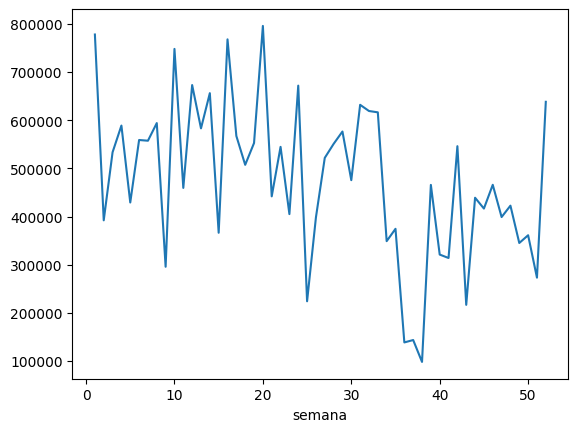

In [20]:
# Crear gráfico simple
vta_sem.plot()
plt.show() # Acostumbrate a utilizar esta línea a fin que solo se muestre el gráfico generado

Proporciona al menos dos conclusiones relevantes.

**CONCLUSIONES**

| # | Conclusión |
| ---- | ---- |
| 1 | Las ventas totales de MT se reducen significativamente entre las semanas 35 a 40 debido a que las mismas corresponden al final del período de vacaciones (Ago - Sep). En estas fechas el tiempo invertido en servicios recreativos -como el turismo- se reduce significativamente, debido a algunos factores como el inicio de clases en institutos y universidades, así como a la necesidad de ahorro para afrontar fechas importantes posteriores en el año como es la navidad. |
| 2 | Se observan mayores ventas entre las semanas 10 a 20, las cuales corresponden aproximadamente a los meses de marzo y abril. Esto se explica porque en estas fechas muchos países tienen vacaciones asociadas a la Semana Santa o el inicio de la primavera (Hemisferio Norte) y los turistas aprovechan estos feriados para viajar. Lo expuesto permitiría inferir además que un grupo significativo de pasajeros de MT proviene de países como Estados Unidos en donde el *Spring Brake* es un momento importante para visitar otras zonas geográficas. | 

Finalmente repite el gráfico con los aspectos formales que estimes necesarios. Utiliza para estos distintos argumentos del método plot así como funciones de la librería **Matplotlib**.

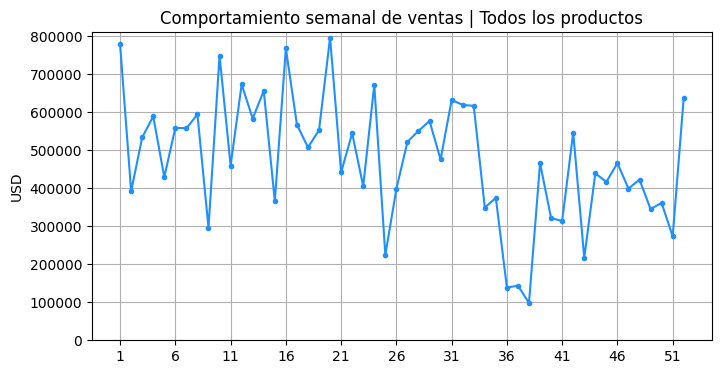

In [21]:
# Crear gráfico con formato
vta_sem.plot(
    title = "Comportamiento semanal de ventas | Todos los productos",
    ylabel = "USD",
    xlabel = "",
    figsize = [8,4],
    grid = True,
    marker = ".",
    color = "dodgerblue",
    ylim = [0,810000]
)
plt.xticks(range(1,53,5))
plt.show()

### ¿Cuál es la venta promedio de barcos cada día de la semana?

Sigue los mismos pasos de la pregunta anterior para dar una respuesta satisfactoria.

In [22]:
# Agregar los datos
vta_dia = df_ventas_final.groupby("dia_semana")['venta_barcos'].mean()
vta_dia

dia_semana
01.Lun    11989.319565
02.Mar    13488.948191
03.Mie     7286.292198
04.Jue    22508.218100
05.Vie    35103.379134
06.Sab    26083.212857
07.Dom     9010.733762
Name: venta_barcos, dtype: float64

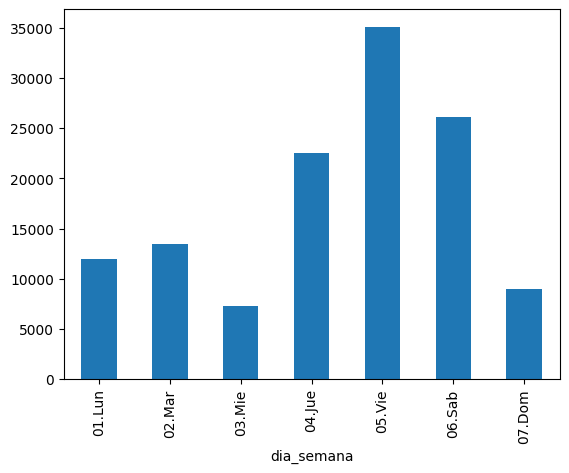

In [23]:
# Crear gráfico simple
vta_dia.plot(
    kind = "bar"
)
plt.show()

**CONCLUSIONES**

| # | Conclusión |
| ---- | ---- |
| 1 | La venta promedio de barcos en la empresa es mayor los días viernes y sábado, lo cual es coherente en cuanto a que los turistas tienden a preferir viajes que se superpongan con los fines de semana para minimizar los días que toman libres en sus trabajos. Esto se complementa también cuando se evidencia una menor venta en los días miércoles (mitad de semana laborable) y domingo (retorno para prepararse para el trabajo). |

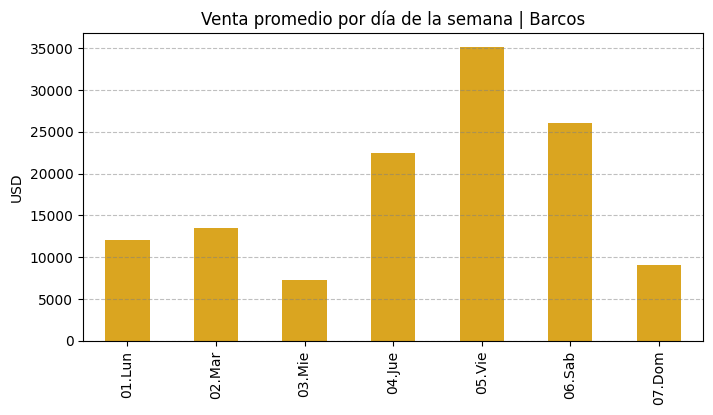

In [24]:
# Crear gráfico con formato
vta_dia.plot(
    kind = "bar",
    title = "Venta promedio por día de la semana | Barcos",
    ylabel = "USD",
    xlabel = "",
    rot = 90,
    figsize = [8,4],
    color = "goldenrod"
)
plt.grid(
    axis = "y", 
    linestyle = "--", 
    color = "gray", 
    alpha = 0.5
)
plt.show()

### ¿Cómo se comportan las ventas por canal?

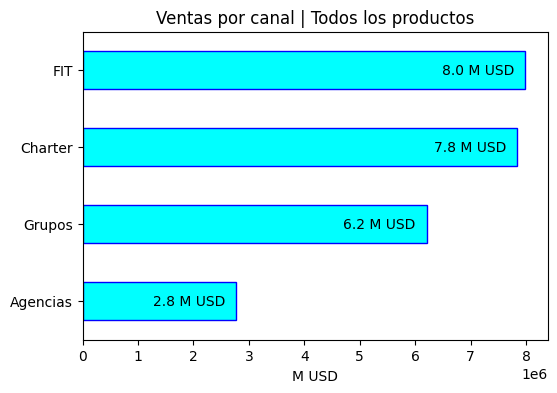

In [25]:
# Ejecutar todos los pasos de agregación y visualización recomendados
vta_canal = df_ventas_final.groupby("canal")['venta_total'].sum().sort_values(ascending = True)

vta_canal.plot(
    kind = "barh",
    title = "Ventas por canal | Todos los productos",
    ylabel = "",
    xlabel = "M USD",
    figsize = [6,4], 
    color = "cyan",
    edgecolor = "blue"
)
i = 0
for c in vta_canal.index:
    plt.annotate(
        text = f"{vta_canal.loc[c]/1000000:.1f} M USD", 
        xy = [vta_canal.loc[c] - 1500000, i - 0.05]
    )
    i += 1
plt.show()

**CONCLUSIONES**

| # | Conclusión |
| ---- | ---- |
| 1 | El canal agencias es el de menor venta total lo cual se explicaría porque la demanda atendida por este canal se asocia a pequeños grupos (generalmente familias o parejas). En cualquier caso se recomendaría que a partir de estos resultados se incentiven las ventas de este canal  en MT ya sea con una mayor inversión de marketing o bien mediante la ampliación del equipo de ventas destinado a este canal. |

## Entendimiento de nuevos datos

Vistos los buenos resultados alcanzados hasta el momento por tu análisis, MT te provee de nueva información constante en el dataset [**paxtours2023.xlsx**](https://github.com/jsaraujo5081/material_curso_data_science/raw/refs/heads/main/datasets/pax_tours2023.xlsx).

Carga esta tabla en tu documento con la función `read_excel` considerando que su extensión es *xlsx*, y a continuación mira su estructura.

In [26]:
# Cargar datos
df_paxtours = pd.read_excel("https://github.com/jsaraujo5081/material_curso_data_science/raw/refs/heads/main/datasets/pax_tours2023.xlsx")

In [27]:
# Mirar la estructura de los datos
df_paxtours.info()

<class 'pandas.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   canal   48 non-null     str  
 1   mes     48 non-null     int64
 2   pax     48 non-null     int64
 3   tours   48 non-null     int64
dtypes: int64(3), str(1)
memory usage: 2.0 KB


El dataframe consta de 48 filas y 4 columnas descritas a continuación:

* canal: Tipo de cliente asociado a la ventas del 2023.
* mes: Mes del 2023 en el cual se hizo el viaje.
* pax: Cantidad de pasajeros que correponden a ese canal y mes de venta.
* tours: Cantidad de grupos que correponden a ese canal y mes de venta.

Estudia este dataset y define un plan de acción para procesarlo y posteriormente unirlo satisfactoriamente con la información que ya tienes sobre venta.

In [28]:
# Generar muestra de los datos
df_paxtours.sample(10)

,canal,mes,pax,tours
10,Agencias,11,87,26
37,WS - Other,2,1371,26
23,Charter,12,38,1
40,WS - Other,5,741,27
16,Charter,5,231,6
5,Agencias,6,60,18
31,WS - FIT,8,387,81
22,Charter,11,67,2
32,WS - FIT,9,152,48
18,Charter,7,170,5


In [29]:
# Obtener casos únicos de columna canal
df_paxtours["canal"].unique()

<ArrowStringArray>
['Agencias', 'Charter', 'WS - FIT', 'WS - Other']
Length: 4, dtype: str

In [30]:
# Obtener un resumen estadistico de pax y tours
df_paxtours[["pax", "tours"]].describe().round(0)

,pax,tours
count,48.0,48.0
mean,321.0,36.0
std,316.0,37.0
min,22.0,1.0
25%,86.0,8.0
50%,194.0,25.0
75%,396.0,42.0
max,1371.0,129.0


**PLAN DE ACCIÓN PARA PREPARACIÓN DE DATOS**

| # | Acción |
| ---- | ---- |
| 1 | Cambiar los valores de la columna canal a fin que se correspondan con los nombres utilizados en los análisis precedentes. |
| 2 | Hacer que los valores de mes se presenten en forma más semántica para que se correspondan con los meses utilizados previamente. |
| 3 | Agregar la información de ventas a niveles de canal y mes para que su detalle sea compatible con la nueva información y puedan unificarse ambas fuentes de datos. |

## Preparación de datos (II)

Pon en marcha el plan de acción definido de manera ordenada y clara.

In [31]:
# Cambiar valores de canal
df_paxtours["canal"] = df_paxtours["canal"].apply(nombres_canal)
df_paxtours["canal"].unique()

<ArrowStringArray>
['Agencias', 'Charter', 'FIT', 'Grupos']
Length: 4, dtype: str

In [32]:
#Ajustar nombres de meses
df_paxtours = df_paxtours.merge(
    cat_mes,
    on = "mes"
)

df_paxtours["mes"] = df_paxtours["mes_nombre"]
df_paxtours = df_paxtours.drop(columns = "mes_nombre")
df_paxtours["mes"].unique()

<ArrowStringArray>
['01.Ene', '02.Feb', '03.Mar', '04.Abr', '05.May', '06.Jun', '07.Jul',
 '08.Ago', '09.Sep', '10.Oct', '11.Nov', '12.Dic']
Length: 12, dtype: str

In [33]:
# Agregar datos de venta a nivel de canal y mes
df_ventas_ag = (
    df_ventas_final
    .groupby(["canal","mes"])
    [["venta_total","venta_barcos","venta_otros"]].sum()
    .reset_index() # Con el método reset_index se establece que las variables de agrupamiento sean columnas del dataset (y no índices)
)
df_ventas_ag.sample(5)

,canal,mes,venta_total,venta_barcos,venta_otros
5,Agencias,06.Jun,264609.30,179120.00,85489.30
39,Grupos,04.Abr,724293.92,390658.53,333635.39
3,Agencias,04.Abr,190679.88,81053.00,109626.88
36,Grupos,01.Ene,354997.11,104974.00,250023.11
10,Agencias,11.Nov,227446.53,126658.12,100788.41


In [34]:
# Unir datos de pax y tours con ventas
df_consolidado = df_ventas_ag.merge(
    df_paxtours,
    on = ["canal", "mes"],
    how = "left" # Se utiliza la forma left para garantizar que todas las filas de ventas esten disponibles
)
df_consolidado.info()

<class 'pandas.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   canal         48 non-null     str    
 1   mes           48 non-null     str    
 2   venta_total   48 non-null     float64
 3   venta_barcos  48 non-null     float64
 4   venta_otros   48 non-null     float64
 5   pax           48 non-null     int64  
 6   tours         48 non-null     int64  
dtypes: float64(3), int64(2), str(2)
memory usage: 3.3 KB


Imprime una muestra de tu dataset consolidado para validar que se encuentre listo para el análisis.

In [35]:
df_consolidado.sample(10)

,canal,mes,venta_total,venta_barcos,venta_otros,pax,tours
8,Agencias,09.Sep,70919.94,57475.92,13444.02,22,8
14,Charter,03.Mar,1060159.05,793336.00,266823.05,229,6
41,Grupos,06.Jun,555853.42,233302.45,322550.97,883,30
32,FIT,09.Sep,453846.90,200670.65,253176.25,152,48
13,Charter,02.Feb,833412.27,606741.60,226670.67,184,5
0,Agencias,01.Ene,520203.81,288574.59,231629.22,148,35
6,Agencias,07.Jul,145111.17,25269.99,119841.18,74,17
46,Grupos,11.Nov,634593.47,404615.95,229977.52,689,31
27,FIT,04.Abr,754561.74,399931.28,354630.46,312,111
19,Charter,08.Ago,267508.28,235915.20,31593.08,46,1


## Análisis de datos (II)

Con la nueva información disponible, continúa respondiendo preguntas de negocio.

### ¿Cuál es el comportamiento mensual del precio pagado por pasajero?

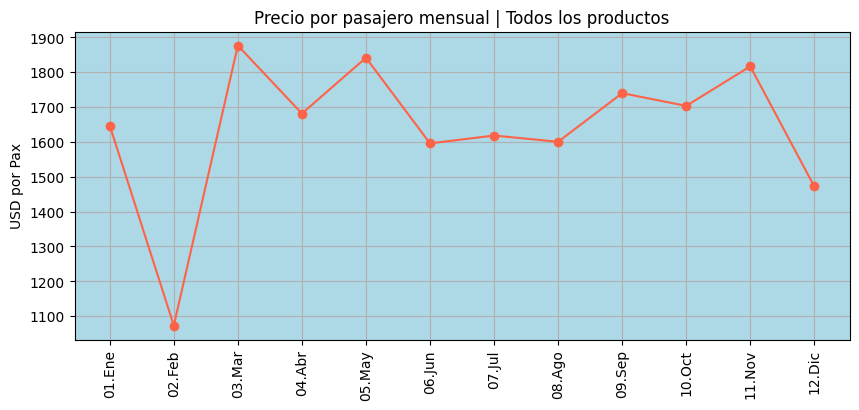

In [36]:
precio_mes = df_consolidado.groupby(["mes"])[["venta_total","pax"]].sum()
precio_mes["precio"] = precio_mes["venta_total"] / precio_mes["pax"]

graf = precio_mes.plot(
    y = "precio",
    legend = False,
    marker = "o",
    title = "Precio por pasajero mensual | Todos los productos",
    ylabel = 'USD por Pax',
    xlabel = "",
    figsize = [10,4],
    xticks = range(0,12),
    rot = 90,
    color = "tomato",
    grid = True
)
graf.set_facecolor("lightblue")
plt.show()

**CONCLUSIONES**

| # | Conclusión |
| ---- | ---- |
| 1 | La reducción en el precio observado en los meses de febrero y diciembre responderían a la aplicación de políticas de descuentos que compensen una potencial baja demanda esperable en el turismo durante estos momentos del año (temporadas bajas poteriores a feriados de navidad y año nuevo). |

### ¿Cómo se comporta el precio pagado por pasajero por canal?

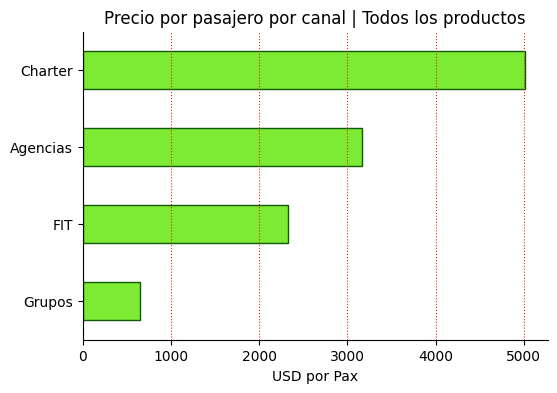

In [37]:
precio_canal = df_consolidado.groupby(["canal"])[["venta_total","pax"]].sum()
precio_canal["precio"] = precio_canal["venta_total"] / precio_canal["pax"]
precio_canal = precio_canal.sort_values(by = "precio")

graf = precio_canal.plot(
    kind = "barh",
    y = "precio",
    legend = False,
    title = "Precio por pasajero por canal | Todos los productos",
    xlabel = "USD por Pax",
    ylabel = "",
    figsize = [6,4],
    color = "#7deb34",
    edgecolor = "#105908"
)

graf.spines["top"].set_visible(False)
graf.spines["right"].set_visible(False)
plt.grid(axis = "x", color = "#d62a0f", linestyle = ":")
plt.show()

**CONCLUSIONES**

| # | Conclusión |
| ---- | ---- |
| 1 | Los charters tiene el valor de precio por pasajero más alto lo cual es consistente con la naturaleza de este canal en cuanto MT recibe un pago por la totalidad de las salidas de barcos sin que esto implique una completa ocupación real. De hecho, las salidas de charters tienen en promedio una ocupación de 65%, por lo que cada pasajero representa un valor de 154% del valor real del crucero. |
| 2 | Si bien el canal agencias tiene una baja participación en las ventas totales, el precio por pasajero es mayor que aquellos observados en otros canales. Esto permite inferir su potencial rentabilidad que sustenta aún más la recomendación de generar una mayor inversión para fortalecer sus actividades. |

### ¿Existen diferencias en el año respecto al tamaño de los tours que viajan por el canal Agencias respecto a los FIT? 

Es importante aclarar que "tamaño de tours" hace referencia a la cantidad de pasajeros en cada tour.

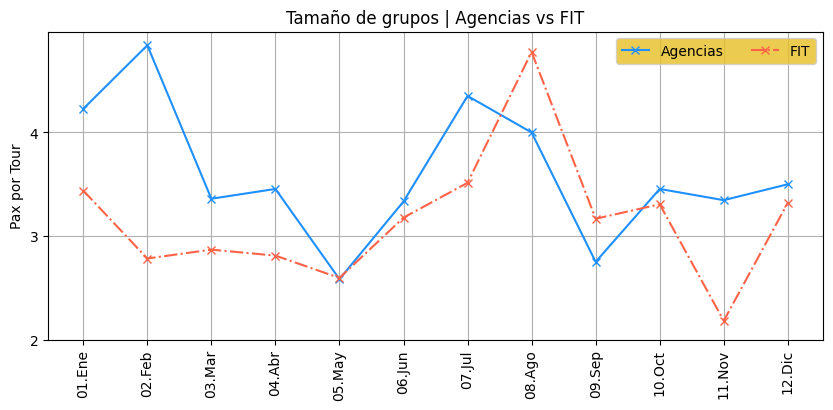

In [38]:
canales_analisis = ["Agencias","FIT"]
pax_tours = df_consolidado.copy().query("canal == @canales_analisis")
pax_tours["pax_por_tour"] = pax_tours["pax"] / pax_tours["tours"]
pax_tours = pax_tours.pivot_table(
    index = "mes",
    columns = "canal",
    values = "pax_por_tour",
    aggfunc = "median"
)

pax_tours.plot(
    title = "Tamaño de grupos | Agencias vs FIT",
    ylabel = "Pax por Tour",
    xlabel = "",
    figsize = [10,4],
    color = ["dodgerblue","tomato"],
    style = ["-","-."],
    marker = "x",
    grid = True,
    rot = 90,
    xticks = range(0,12),
    yticks = range(2,5)
)
plt.legend(title = "", ncol = 2, facecolor = "#e8be25")
plt.show()

**CONCLUSIONES**

| # | Conclusión |
| ---- | ---- |
| 1 | Agencias y FIT compiten con mayor intensidad en los meses de verano (Jun - Jul - Ago) en el nicho de viajes "familiares". Lo anterior queda en evidencia al observar que ambos tienen tamaños de grupos similares y con más de 3 pasajeros por tour. |
| 2 | Entre los meses de Febrero y Abril, e igual en Noviembre, El canal FIT tiene un enfoque más asociado a parejas o grupos familares reducidos (con tamaños de grupo cercanos a 2). Por su parte, Agencias sigue atendiendo a mercados familiares. Quizás esto es parte de la explicación del porqué las ventas por este último canal son menores, visto que en períodos de clases en institutos y universidades la demanda por viajes familiares es significativamente menor. |